# Workshop: เริ่มต้น pandas กับข้อมูล Titanic 🚢



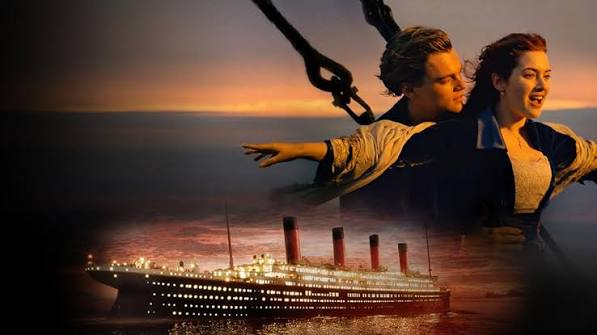


| ส่วน | เนื้อหา | เวลาโดยประมาณ |
|---|---|---|
| 1 | สำรวจข้อมูล (Data exploration) | 5 นาที |
| 2 | ข้อมูลซ้ำ (Duplicates) | 10 นาที |
| 3 | ค่าที่หายไป (Missing values) | 10 นาที |
| 4 | แปลงข้อมูล (Data transformation) | 10 นาที |
| 5 | นับและสรุปข้อมูลตามกลุ่ม (`groupby`) | 10 นาที |
| 6 | รวมตาราง (`merge`) | 20 นาที |
| 7 | วาดกราฟ (seaborn + plotly) | 30 นาที |

## **0.โหลดข้อมูล**

ข้อมูล Titanic คือรายชื่อผู้โดยสารเรือไททานิก (ปี 1912) จำนวน 891 คน ว่าใครรอดชีวิตบ้าง


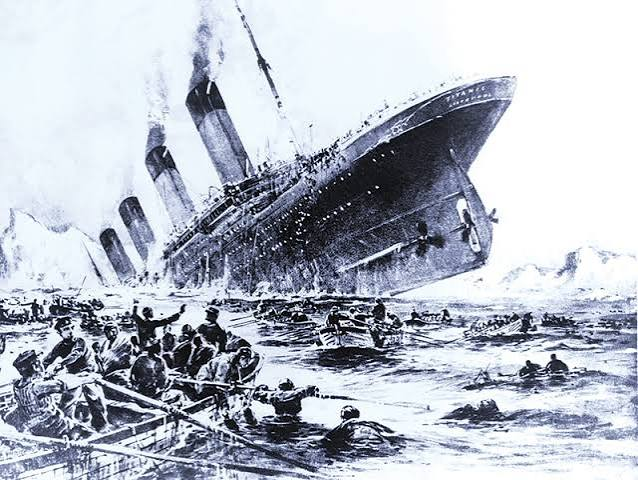

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)
df.sample(7)
# หรือถ้าใช้ไฟล์ในเครื่อง:
# df = pd.read_csv("titanic.csv")

- คำอธิบายคอลัมน์ (Data dictionary)

| คอลัมน์ | ความหมาย | ตัวอย่างค่า |
|---|---|---|
| `survived` | รอดชีวิตหรือไม่ (1 = รอด, 0 = ไม่รอด) | 0, 1 |
| `pclass` | ชั้นตั๋วโดยสาร (1 = ชั้นหนึ่ง) | 1, 2, 3 |
| `sex` | เพศ | male, female |
| `age` | อายุ (ปี) | 22.0 |
| `sibsp` | จำนวนพี่น้อง/คู่สมรสที่มาด้วย | 0, 1 |
| `parch` | จำนวนพ่อแม่/ลูกที่มาด้วย | 0, 2 |
| `fare` | ค่าตั๋ว | 7.25 |
| `embarked` | ท่าเรือที่ขึ้น (C = Cherbourg, Q = Queenstown, S = Southampton) | S |
| `class` | ชั้นตั๋ว (แบบข้อความ) | First, Third |
| `who` | ผู้ชาย / ผู้หญิง / เด็ก | man, woman, child |
| `adult_male` | เป็นผู้ชายวัยผู้ใหญ่หรือไม่ | True, False |
| `deck` | ชั้นดาดฟ้าของห้องพัก | A–G |
| `embark_town` | ชื่อเมืองท่าที่ขึ้นเรือ | Southampton |
| `alive` | รอดชีวิต (แบบข้อความ) | yes, no |
| `alone` | เดินทางคนเดียวหรือไม่ | True, False |

> 🔎 สังเกต: บางคอลัมน์บอกเรื่องเดียวกันซ้ำ เช่น `survived` กับ `alive`, `pclass` กับ `class` — เป็นเรื่องปกติในข้อมูลจริง

---
## 1.**สำรวจข้อมูล (Data exploration)**

ก่อนวิเคราะห์อะไร ให้ถาม 4 คำถามนี้เสมอ:
1. ข้อมูลมี **กี่แถว กี่คอลัมน์**?
2. หน้าตาข้อมูล **เป็นอย่างไร**?
3. แต่ละคอลัมน์เป็น **ชนิดข้อมูล** อะไร (ตัวเลข / ข้อความ)?
4. ค่าในแต่ละคอลัมน์ **กระจายตัว** อย่างไร?

### 1.1 ขนาดของข้อมูล — `.shape`
ได้ผลเป็น `(จำนวนแถว, จำนวนคอลัมน์)`

In [ ]:
df.shape

### 1.2 ดูตัวอย่างข้อมูล — `.head()`, `.tail()`, `.sample()`

In [ ]:
# 5 แถวแรก
df.head()

In [ ]:
# 3 แถวสุดท้าย (ใส่ตัวเลขในวงเล็บเพื่อกำหนดจำนวนแถว)
df.tail(3)

In [ ]:
# สุ่มมา 5 แถว — ช่วยให้เห็นข้อมูลช่วงกลางตาราง
# random_state=1 ทำให้ทุกคนได้แถวเดียวกัน
df.sample(5, random_state=1)

### 1.3 ชื่อคอลัมน์และชนิดข้อมูล — `.columns`, `.dtypes`, `.info()`

ชนิดข้อมูลที่พบบ่อย:
- `int64` = จำนวนเต็ม
- `float64` = ทศนิยม
- `object` หรือ `str` = ข้อความ
- `bool` = จริง/เท็จ (True/False)

In [ ]:
df.columns

In [ ]:
df.dtypes

`.info()` สรุปทุกอย่างในคำสั่งเดียว — **ดูคอลัมน์ `Non-Null Count`** ให้ดี
ถ้าตัวเลขน้อยกว่า 891 แปลว่าคอลัมน์นั้นมี **ค่าว่าง** (เราจะกลับมาดูในส่วนที่ 3)

In [ ]:
df.info()

### 1.4 สถิติเบื้องต้น — `.describe()`

สำหรับคอลัมน์ตัวเลข:
- `count` จำนวนค่าที่ไม่ว่าง · `mean` ค่าเฉลี่ย · `std` ส่วนเบี่ยงเบนมาตรฐาน
- `min` / `max` ค่าต่ำสุด / สูงสุด · `25%` `50%` `75%` ควอไทล์ (`50%` = มัธยฐาน, median)

In [ ]:
df.describe()

🔎 **ลองสังเกต:**
- `age` มี count น้อยกว่าคอลัมน์อื่น → มีค่าว่าง
- `fare` ต่ำสุดเป็น 0 → มีคนได้ตั๋วฟรีหรือข้อมูลผิด? (ในงานจริงต้องถามเจ้าของข้อมูล)
- `survived` เป็น 0/1 ดังนั้นค่า `mean` คือ **สัดส่วนคนรอด** พอดี

สำหรับคอลัมน์ข้อความ ใช้ `exclude="number"`คือ ไม่ต้องแสดงข้อมูลคอลัมน์ที่เป็น number:
- `unique` จำนวนค่าที่ไม่ซ้ำกัน · `top` ค่าที่พบบ่อยที่สุด · `freq` จำนวนครั้งที่พบ

In [ ]:
df.describe(exclude="number")

### 1.5 เลือกคอลัมน์และนับค่า — `df["ชื่อคอลัมน์"]`, `.value_counts()`

In [ ]:
# เลือก 1 คอลัมน์ ใช้วงเล็บเหลี่ยม 1 ชั้น
df["sex"].head()

In [ ]:
# เลือกหลายคอลัมน์ ใช้วงเล็บเหลี่ยม 2 ชั้น [[ ]]
df[["sex", "age", "survived"]].head()

In [ ]:
# นับว่าแต่ละค่ามีกี่แถว
df["sex"].value_counts()

In [ ]:
# normalize=True แสดงเป็นสัดส่วน (คูณ 100 = เปอร์เซ็นต์)
df["class"].value_counts(normalize=True)

In [ ]:
# dropna=False ให้นับค่าว่าง (NaN) ด้วย — มีประโยชน์มากตอนตรวจข้อมูล
df["embarked"].value_counts(dropna=False)

### 1.6 กรองแถว (Filter) — `df[เงื่อนไข]`

เงื่อนไขใช้เครื่องหมาย `==` (เท่ากับ), `!=` (ไม่เท่ากับ), `>`, `<`, `>=`, `<=`
ถ้ามีหลายเงื่อนไข ใช้ `&` (และ) หรือ `|` (หรือ) และ **ต้องใส่วงเล็บแต่ละเงื่อนไข**

In [ ]:
# ผู้โดยสารที่อายุน้อยกว่า 10 ปี
kids = df[df["age"] < 10]
print("จำนวนเด็กอายุต่ำกว่า 10 ปี:", len(kids))
kids.head()

In [ ]:
# ผู้หญิงที่นั่งชั้นหนึ่ง
df[(df["sex"] == "female") & (df["pclass"] == 1)].head()

### ✏️ แบบฝึกหัด 1

**1.1** ค่าตั๋ว (`fare`) แพงที่สุดเท่าไร? (ใช้ `.max()`)

In [ ]:
# เขียนโค้ดตรงนี้

**1.2** ผู้โดยสารขึ้นเรือจากท่าไหนมากที่สุด? (ใช้ `value_counts()` กับ `embark_town`)

In [ ]:
# เขียนโค้ดตรงนี้

**1.3** มีผู้โดยสารชั้น 3 (`pclass == 3`) ที่รอดชีวิต (`survived == 1`) กี่คน?

In [ ]:
# เขียนโค้ดตรงนี้ (ใบ้: กรองด้วย 2 เงื่อนไข แล้วใช้ len())

**1.4 ⏭️ (ท้าทาย)** อัตรารอดชีวิตของผู้หญิงกับผู้ชายต่างกันแค่ไหน?
ใบ้: `df.groupby("sex")["survived"].mean()`

In [ ]:
# เขียนโค้ดตรงนี้

---
## **2. ตรวจข้อมูลซ้ำ (Duplicates)**

ข้อมูลซ้ำเกิดได้จากหลายสาเหตุ เช่น กรอกข้อมูลซ้ำ, รวมไฟล์ (concat) แล้วมีแถวทับกัน, ระบบ export ซ้ำ
ถ้าไม่ตรวจ จะทำให้ **นับจำนวนเกินจริง** และค่าสถิติเพี้ยน

### 2.1 ตัวอย่าง

In [ ]:
patients = pd.DataFrame({
    "patient_id": [101, 102, 103, 102, 104, 105],
    "name":       ["สมชาย", "สมหญิง", "มานี", "สมหญิง", "ปิติ", "มานี"],
    "age":        [45, 38, 60, 38, 52, 61],
})
patients

`.duplicated()` ตอบ True/False ทีละแถวว่า **แถวนี้ซ้ำกับแถวก่อนหน้าทุกคอลัมน์** หรือไม่
(แถวที่เจอครั้งแรกจะเป็น False ส่วนแถวที่เจอครั้งต่อไปเป็น True)

In [ ]:
patients.duplicated()

In [ ]:
# True นับเป็น 1, False นับเป็น 0 → ใช้ .sum() นับจำนวนแถวซ้ำได้
patients.duplicated().sum()

🔎 สังเกต: แถว "มานี" สองแถว **ไม่ถูกนับว่าซ้ำ** เพราะ `patient_id` และ `age` ต่างกัน
→ อาจเป็นคนละคนที่ชื่อเหมือนกัน หรือกรอกข้อมูลผิด — **ต้องใช้ความรู้เรื่องข้อมูลตัดสิน ไม่ใช่โค้ดอย่างเดียว**

### 2.2 ตรวจซ้ำเฉพาะบางคอลัมน์ — `subset=`
บ่อยครั้งเราสนใจว่า **รหัส (ID) ซ้ำหรือไม่** มากกว่าทั้งแถวซ้ำ

In [ ]:
# patient_id ซ้ำไหม?
patients.duplicated(subset=["patient_id"]).sum()

In [ ]:
# ชื่อซ้ำไหม?  keep=False = แสดงทุกแถวที่ซ้ำ (รวมแถวแรกด้วย) ช่วยให้เทียบกันได้
patients[patients.duplicated(subset=["name"], keep=False)]

### 2.3 ลบแถวซ้ำ — `.drop_duplicates()`
คำสั่งนี้ **ไม่ได้แก้ตารางเดิม** แต่สร้างตารางใหม่ ต้องเก็บใส่ตัวแปรเอง

In [ ]:
patients_clean = patients.drop_duplicates()
patients_clean

สังเกตว่าเลข index (เลขซ้ายสุด) ข้ามไป 3 → ใช้ `.reset_index(drop=True)` เพื่อเรียงเลขใหม่

In [ ]:
patients_clean = patients.drop_duplicates().reset_index(drop=True)
patients_clean

### 2.4 กลับมาที่ Titanic

In [ ]:
n_dup = df.duplicated().sum()
print("จำนวนแถวที่ซ้ำทุกคอลัมน์:", n_dup)

In [ ]:
# ดูตัวอย่างแถวที่ซ้ำ เรียงให้แถวที่เหมือนกันอยู่ติดกัน
dups = df[df.duplicated(keep=False)]
dups.sort_values(by=list(df.columns)).head(6)

### 🤔 คำถามชวนคิด: แถวพวกนี้ "ซ้ำจริง" หรือไม่?

ข้อมูล Titanic ชุดนี้ **ไม่มีชื่อและรหัสผู้โดยสาร**
ดังนั้นผู้ชายชั้น 3 อายุ 25 ปี ขึ้นที่ Southampton มาคนเดียว ไม่รอด… อาจมี **หลายคนจริง ๆ** ที่ข้อมูลเหมือนกันทุกช่อง

ถ้าเราลบทิ้ง 107 แถว = **ลบผู้โดยสารจริงทิ้งไปราว 12%** และทำให้อัตรารอดชีวิตเพี้ยน 👇

In [ ]:
print("อัตรารอดชีวิต (ข้อมูลเดิม)       :", round(df["survived"].mean(), 3))
print("อัตรารอดชีวิต (หลังลบแถวซ้ำ)   :", round(df.drop_duplicates()["survived"].mean(), 3))

### ✅ หลักการตัดสินใจเรื่องข้อมูลซ้ำ
| สถานการณ์ | ควรทำอย่างไร |
|---|---|
| มีคอลัมน์รหัส (ID) และรหัสซ้ำ + ข้อมูลเหมือนกันทุกช่อง | ลบได้ — น่าจะเป็นการบันทึกซ้ำ |
| รหัสซ้ำ แต่ข้อมูลบางช่องต่างกัน | **อย่าเพิ่งลบ** — ตรวจสอบกับต้นทางว่าแถวไหนถูก |
| ไม่มีรหัส แถวเหมือนกันทุกช่อง (เช่น Titanic ชุดนี้) | **ไม่ควรลบ** — อาจเป็นคนละคน |

ในตัวอย่างนี้เราจึง **เก็บทุกแถวไว้** และไปต่อที่เรื่องค่าที่หายไป

### ✏️ แบบฝึกหัด 2

**2.1** ในข้อมูล Titanic ถ้าดูแค่คอลัมน์ `sex`, `age`, `pclass` จะมีแถวที่ซ้ำกันกี่แถว?
ทำไมตัวเลขถึงมากกว่า 107 มาก?

In [ ]:
# เขียนโค้ดตรงนี้ (ใบ้: ใช้ subset=)

**2.2** สร้างตารางผู้ป่วยต่อไปนี้ แล้วหาว่า `hn` (เลขประจำตัวผู้ป่วย) ไหนซ้ำบ้าง และลบแถวที่ซ้ำ **ทุกคอลัมน์** ออก

In [ ]:
visits = pd.DataFrame({
    "hn":    ["A01", "A02", "A01", "A03", "A02", "A01"],
    "visit": ["2026-01-05", "2026-01-06", "2026-01-05", "2026-01-07", "2026-02-10", "2026-03-01"],
    "dx":    ["C50", "C34", "C50", "C18", "C34", "C50"],
})

# เขียนโค้ดต่อตรงนี้

---
## **3. ค่าที่หายไป (Missing values)**

ใน pandas ค่าที่หายไปจะแสดงเป็น **`NaN`** (Not a Number) หรือ `None`
ถ้าไม่จัดการ บางคำสั่งจะ error หรือได้ผลที่ผิดโดยไม่รู้ตัว

### 3.1 ตรวจหาค่าว่าง — `.isna()`
`.isna()` ตอบ True ตรงช่องที่ว่าง แล้วใช้ `.sum()` นับรายคอลัมน์

In [ ]:
df.isna().head()

In [ ]:
# จำนวนค่าว่างในแต่ละคอลัมน์
df.isna().sum()

In [ ]:
# สรุปเป็นตารางสวย ๆ เฉพาะคอลัมน์ที่มีค่าว่าง
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
})
missing[missing["n_missing"] > 0].sort_values("n_missing", ascending=False)

🔎 **สรุปค่าว่างใน Titanic**
| คอลัมน์ | ว่าง | ประมาณ % | ความหมาย |
|---|---|---|---|
| `deck` | 688 | 77% | ส่วนใหญ่ไม่รู้ว่าพักชั้นไหน |
| `age` | 177 | 20% | ไม่รู้อายุ 1 ใน 5 คน |
| `embarked`, `embark_town` | 2 | 0.2% | ไม่รู้ท่าเรือที่ขึ้น |

→ แต่ละคอลัมน์ว่าง **มากน้อยต่างกัน** จึงควรใช้ **วิธีจัดการต่างกัน**

### 3.2 ดูแถวที่มีค่าว่าง

In [ ]:
# แถวที่ embarked ว่าง
df[df["embarked"].isna()]

In [ ]:
# แถวที่ age ว่าง (ดู 5 แถวแรก)
df[df["age"].isna()].head()

### 3.3 วิธีจัดการค่าว่าง 3 แบบหลัก

| วิธี | คำสั่ง | ใช้เมื่อ |
|---|---|---|
| **A. ลบคอลัมน์** | `df.drop(columns=[...])` | คอลัมน์ว่างเยอะมาก (เช่น > 50–70%) และไม่จำเป็น |
| **B. ลบแถว** | `df.dropna(subset=[...])` | แถวที่ว่างมีจำนวนน้อยมาก |
| **C. เติมค่า (impute)** | `df[col].fillna(ค่า)` | ว่างพอสมควร แต่ยังอยากเก็บแถวไว้ |

⚠️ เราจะทำงานบน **สำเนา** ของข้อมูล (`.copy()`) เพื่อให้ข้อมูลดิบ `df` ยังอยู่ครบ

In [ ]:
df_clean = df.copy()

#### A. ลบคอลัมน์ `deck` (ว่าง 77%)

In [ ]:
df_clean = df_clean.drop(columns=["deck"])
df_clean.shape

#### B. ลบแถวที่ `embarked` ว่าง (มีแค่ 2 แถว)
ใช้ `subset=` เพื่อบอกว่าให้ดูค่าว่างเฉพาะคอลัมน์นี้

⚠️ ถ้าใช้ `dropna()` เฉย ๆ โดยไม่ใส่ `subset` จะลบ **ทุกแถวที่มีค่าว่างสักช่อง** → ลองดูว่าจะเหลือกี่แถว!

In [ ]:
print("ถ้าใช้ dropna() ทั้งตาราง (ข้อมูลเดิม) จะเหลือ:", len(df.dropna()), "แถว จาก", len(df))

In [ ]:
df_clean = df_clean.dropna(subset=["embarked"])
print("หลังลบแถวที่ embarked ว่าง เหลือ:", len(df_clean), "แถว")

#### C. เติมค่าอายุ (`age`) ที่ว่างด้วยค่ามัธยฐาน (median)

ทำไมใช้ **median** แทน **mean**? เพราะ median ไม่ถูกดึงด้วยค่าสุดโต่ง (เช่น ผู้สูงอายุไม่กี่คน)

In [ ]:
age_median = df_clean["age"].median()
age_mean = df_clean["age"].mean()
print("median:", age_median, "| mean:", round(age_mean, 1))

In [ ]:
# เก็บไว้ก่อนว่าแถวไหนเคยว่าง (ใช้เปรียบเทียบ และเป็นแนวปฏิบัติที่ดี)
df_clean["age_was_missing"] = df_clean["age"].isna()

# เติมค่า แล้วเขียนทับคอลัมน์เดิม
df_clean["age"] = df_clean["age"].fillna(age_median)

df_clean["age"].isna().sum()

### 3.4 ตรวจซ้ำอีกครั้ง — ต้องไม่เหลือค่าว่าง ✅

In [ ]:
df_clean.isna().sum()

In [ ]:
print("ก่อน :", df.shape, "| ค่าว่างรวม", df.isna().sum().sum())
print("หลัง :", df_clean.shape, "| ค่าว่างรวม", df_clean.isna().sum().sum())

### 3.5 ⏭️ รู้ไว้: ค่าว่างที่ "ซ่อนตัว"
ในข้อมูลจริง (เช่น ไฟล์ Excel จากหน่วยงาน) ค่าว่างมักไม่ได้มาเป็นช่องว่างจริง ๆ
แต่มาเป็นข้อความ เช่น `"-"`, `"ไม่ทราบ"`, `"N/A"`, `999` → `.isna()` **จะมองไม่เห็น**

In [ ]:
import numpy as np

raw = pd.DataFrame({
    "hn":  ["A01", "A02", "A03", "A04"],
    "age": ["45", "-", "ไม่ทราบ", "60"],
    "stage": ["II", "N/A", "III", ""],
})
print("isna() เห็นค่าว่างกี่ช่อง:", raw.isna().sum().sum())
raw

In [ ]:
# แปลงข้อความที่หมายถึง "ไม่มีข้อมูล" ให้เป็น NaN
fixed = raw.replace(["-", "ไม่ทราบ", "N/A", ""], np.nan)
print("หลังแปลง isna() เห็นค่าว่าง:", fixed.isna().sum().sum(), "ช่อง")
fixed

### ✏️ แบบฝึกหัด 3

**3.1** คอลัมน์ `embark_town` มีค่าว่างกี่ช่องในข้อมูลดิบ `df`? และใน `df_clean` เหลือกี่ช่อง? ทำไม?

In [ ]:
# เขียนโค้ดตรงนี้

**3.2** แทนที่จะลบ 2 แถวที่ `embarked` ว่าง ให้ลอง **เติมด้วยค่าที่พบบ่อยที่สุด (mode)** ลงในสำเนาใหม่
ใบ้: `df["embarked"].mode()[0]` จะได้ค่าที่พบบ่อยที่สุด

In [ ]:
df_ex = df.copy()

# เขียนโค้ดต่อตรงนี้

**3.3** เติมอายุที่ว่างด้วย **mean** แทน median ลงใน `df_ex` แล้วเปรียบเทียบค่าเฉลี่ยอายุก่อนและหลังเติม — เปลี่ยนไปไหม? ทำไม?

In [ ]:
# เขียนโค้ดตรงนี้

---
## **4. แปลงข้อมูล (Data transformation)**

บางครั้งข้อมูลอยู่ในรูปแบบที่ยังไม่ตรงกับที่เราต้องการ เช่น
- เพศเขียนเป็น `male` / `female` แต่ระบบทะเบียนต้องการเป็นรหัส `1` / `2`
- ท่าเรือเขียนเป็นตัวย่อ `S` / `C` / `Q` แต่อยากได้ชื่อเต็ม
- อายุเป็นตัวเลข แต่อยากแบ่งเป็นกลุ่ม เด็ก / ผู้ใหญ่ / ผู้สูงอายุ

เราจะเขียน **ฟังก์ชัน** เพื่อบอกว่าแปลงอย่างไร แล้วใช้ `.apply()` แปลงทั้งคอลัมน์ในคำสั่งเดียว

> 💡 เราใช้ `df_clean` (ที่จัดการค่าว่างแล้ว) เพราะถ้าเจอค่าว่าง ฟังก์ชันบางอย่างจะ error

### 4.1 ตัวอย่างที่ 1: แปลงเพศเป็นรหัส (1 = ชาย, 2 = หญิง)
ฟังก์ชันนี้รองรับหลายแบบการเขียน (`M`, `Male`, `man`, …) เผื่อใช้กับข้อมูลจากแหล่งอื่นได้ด้วย

In [ ]:
def standardize_sex(sex_str):
    # แปลงตัวอักษรให้เป็นพิมพ์ใหญ่ทั้งหมดก่อน
    sex_str = sex_str.upper()

    # Male variations
    if sex_str in ["1", "M", "MALE", "MAN"]:
        return "1"
    # Female variations
    elif sex_str in ["2", "F", "FEMALE", "WOMAN"]:
        return "2"
    else:
        return "error"

**ขั้นที่ 1: ทดสอบกับค่าทีละตัวก่อนเสมอ**

In [ ]:
print(standardize_sex("male"))
print(standardize_sex("Female"))
print(standardize_sex("M"))
print(standardize_sex("abc"))   # ค่าที่ไม่รู้จัก → error

**ขั้นที่ 2: ใช้กับทั้งคอลัมน์ด้วย `.apply()`** แล้วเก็บเป็นคอลัมน์ใหม่
(ใส่แค่ชื่อฟังก์ชัน **ไม่ต้องมีวงเล็บ** `()` ต่อท้าย)

In [ ]:
df_clean["sex_code"] = df_clean["sex"].apply(standardize_sex)
df_clean[["sex", "sex_code"]].head()

**ขั้นที่ 3: ตรวจผล** — จำนวนต้องตรงกัน และต้องไม่มี `error`

In [ ]:
print(df_clean["sex"].value_counts())
print()
print(df_clean["sex_code"].value_counts())

### 4.2 ตัวอย่างที่ 2: แปลงตัวย่อท่าเรือเป็นชื่อเต็ม
`S` = Southampton, `C` = Cherbourg, `Q` = Queenstown

In [ ]:
def port_name(code):
    if code == "S":
        return "Southampton"
    elif code == "C":
        return "Cherbourg"
    elif code == "Q":
        return "Queenstown"
    else:
        return "error"


df_clean["port_name"] = df_clean["embarked"].apply(port_name)
df_clean[["embarked", "port_name"]].head()

ข้อมูลนี้มีคอลัมน์ `embark_town` อยู่แล้ว → ใช้ **เช็กคำตอบ** ได้ว่าเราแปลงถูกทุกแถวไหม
`(คอลัมน์ A == คอลัมน์ B).all()` จะได้ `True` ถ้าตรงกันทุกแถว

In [ ]:
(df_clean["port_name"] == df_clean["embark_town"]).all()

### 4.3 ตัวอย่างที่ 3: แบ่งอายุเป็นกลุ่ม
ใช้ `<` (น้อยกว่า) เปรียบเทียบตัวเลข — Python จะตรวจเงื่อนไข **จากบนลงล่าง** เจอข้อไหนจริงก่อนก็ return เลย

In [ ]:
def age_group(age):
    if age < 15:
        return "child"
    elif age < 60:
        return "adult"
    else:
        return "elderly"


print(age_group(8), age_group(35), age_group(70))

In [ ]:
df_clean["age_group"] = df_clean["age"].apply(age_group)
df_clean["age_group"].value_counts()

🎉 ได้คอลัมน์ใหม่แล้ว ลองใช้ตอบคำถาม: **กลุ่มอายุไหนรอดชีวิตมากที่สุด?**

In [ ]:
df_clean.groupby("age_group")["survived"].mean()

### ✏️ แบบฝึกหัด 4

**4.1** เขียนฟังก์ชัน `class_number` แปลงคอลัมน์ `class` (`First` / `Second` / `Third`) เป็นตัวเลข `1` / `2` / `3`
แล้วเช็กคำตอบกับคอลัมน์ `pclass`

In [ ]:
def class_number(c):
    # เขียนโค้ดต่อตรงนี้
    pass

# df_clean["class_no"] = df_clean["class"].apply(class_number)
# (df_clean["class_no"] == df_clean["pclass"]).all()

**4.2** เขียนฟังก์ชันแปลงคอลัมน์ `alive` (`yes` / `no`) เป็น `1` / `0` แล้วเช็กคำตอบกับคอลัมน์ `survived`

In [ ]:
# เขียนโค้ดตรงนี้

**4.3 ⏭️ (ท้าทาย)** เขียนฟังก์ชัน `fare_level` แบ่งค่าตั๋ว (`fare`) เป็น 3 ระดับ
- `"low"` ถ้าน้อยกว่า 10
- `"medium"` ถ้า 10 ถึงน้อยกว่า 50
- `"high"` ถ้า 50 ขึ้นไป

แล้วหาว่าแต่ละระดับมีกี่คน และอัตรารอดชีวิตเป็นเท่าไร

In [ ]:
# เขียนโค้ดตรงนี้

---
## **5. นับและสรุปข้อมูลตามกลุ่ม (`groupby`)**

คำถามที่เจอบ่อยที่สุดในงานข้อมูลคือ **"แต่ละกลุ่มมีกี่คน?"** เช่น ผู้ป่วยแต่ละจังหวัดมีกี่ราย, แต่ละเพศมีกี่คน
`groupby` ทำงานเหมือน **Pivot Table ใน Excel** มี 3 ขั้น:

```
1. แบ่งกลุ่ม (split)      →  แยกแถวตามค่าในคอลัมน์ เช่น First / Second / Third
2. คำนวณ (apply)          →  นับ / รวม / เฉลี่ย ในแต่ละกลุ่ม
3. รวมผล (combine)        →  ได้ตารางสรุป 1 แถวต่อ 1 กลุ่ม
```
รูปแบบคำสั่ง: `df.groupby("คอลัมน์ที่ใช้แบ่งกลุ่ม")["คอลัมน์ที่จะคำนวณ"].วิธีคำนวณ()`

### 5.1 นับจำนวนแถวในแต่ละกลุ่ม — `.size()`

In [ ]:
# ผู้โดยสารแต่ละชั้นตั๋วมีกี่คน
df_clean.groupby("class").size()

> 💡 ได้ผลเหมือน `df_clean["class"].value_counts()` — แต่ `groupby` ทำได้มากกว่า เช่น แบ่งหลายคอลัมน์ และคำนวณอย่างอื่นได้

### 5.2 คำนวณค่าอื่นในแต่ละกลุ่ม — `.sum()`, `.mean()`, `.min()`, `.max()`
คอลัมน์ `survived` เป็น 0/1 จึงใช้ได้ 2 แบบ:
- `.sum()` = **จำนวนคน** ที่รอด
- `.mean()` = **สัดส่วน** ที่รอด

In [ ]:
# จำนวนคนที่รอดในแต่ละชั้น
df_clean.groupby("class")["survived"].sum()

In [ ]:
# อัตรารอดชีวิตในแต่ละชั้น (คูณ 100 เป็น %)
(df_clean.groupby("class")["survived"].mean() * 100).round(1)

In [ ]:
# อายุเฉลี่ยของแต่ละชั้น
df_clean.groupby("class")["age"].mean().round(1)

### 5.3 แบ่งกลุ่มด้วย 2 คอลัมน์
ใส่ชื่อคอลัมน์เป็น **list** `["คอลัมน์1", "คอลัมน์2"]`

In [ ]:
# จำนวนผู้โดยสาร แยกตามชั้นตั๋ว และเพศ
df_clean.groupby(["class", "sex"]).size()

ผลลัพธ์ยาวลงมาอ่านยาก → ใช้ `.unstack()` พลิกกลุ่มที่ 2 (sex) ขึ้นไปเป็นคอลัมน์ ได้ตารางแบบ Pivot Table

In [ ]:
df_clean.groupby(["class", "sex"]).size().unstack()

In [ ]:
# อัตรารอดชีวิต แยกตามชั้นตั๋วและเพศ
(df_clean.groupby(["class", "sex"])["survived"].mean() * 100).round(1).unstack()

🔎 ผู้หญิงชั้นหนึ่งรอดเกือบทั้งหมด ส่วนผู้ชายชั้นสามรอดไม่ถึง 1 ใน 6

### 5.4 หลายค่าสรุปพร้อมกันในตารางเดียว — `.agg()`
รูปแบบ: `ชื่อคอลัมน์ผลลัพธ์=("คอลัมน์ที่จะคำนวณ", "วิธีคำนวณ")`

In [ ]:
summary = df_clean.groupby("class").agg(
    n_passengers=("survived", "size"),   # จำนวนคน
    n_survived=("survived", "sum"),      # จำนวนคนรอด
    survival_rate=("survived", "mean"),  # อัตรารอด
    mean_age=("age", "mean"),            # อายุเฉลี่ย
    mean_fare=("fare", "mean"),          # ค่าตั๋วเฉลี่ย
)
summary.round(2)

> 💡 ใส่ `.reset_index()` ต่อท้าย ถ้าอยากให้ชื่อกลุ่มกลายเป็นคอลัมน์ปกติ (สะดวกตอนบันทึกเป็น Excel/CSV)

In [ ]:
summary.round(2).reset_index()

### ✏️ แบบฝึกหัด 5

**5.1** ผู้โดยสารขึ้นเรือจากแต่ละเมืองท่า (`embark_town`) กี่คน?

In [ ]:
# เขียนโค้ดตรงนี้

**5.2** นับจำนวนผู้โดยสาร แยกตามกลุ่มอายุ (`age_group`) และเพศ (`sex`) แล้วแสดงเป็นตารางด้วย `.unstack()`

In [ ]:
# เขียนโค้ดตรงนี้

**5.3** สร้างตารางสรุปแยกตาม `embark_town` ที่มี: จำนวนคน, จำนวนคนรอด, อัตรารอด และค่าตั๋วเฉลี่ย

In [ ]:
# เขียนโค้ดตรงนี้ (ใบ้: ดูตัวอย่าง 5.4)

## **6 รวมตาราง — `.merge()`**
- การเชื่อมข้อมูล 2 ตาราง คือการนำข้อมูลจาก 2 ตารางมาต่อกันข้างๆ โดยใช้ 'รหัสอ้างอิงร่วม' สรุปประเภทการใช้งานหลักได้แก่:


1.   Inner Join: ดึงมาเฉพาะข้อมูลที่มีตรงกันทั้ง 2 ตาราง
2.   Left Join: ข้อมูลตารางซ้ายมาครบ + ดึงข้อมูลตารางขวาเฉพาะที่จับคู่ได้
3.   Right Join: ข้อมูลตารางขวามาครบ + ดึงข้อมูลตารางซ้ายเฉพาะที่จับคู่ได้
4.   Full Join: รวมข้อมูลทั้งหมดของทั้ง 2 ตารางเข้าด้วยกัน"

- ใน Pandas เราสามารถใช้

``` python
pd.merge(df1, df2, on='ID', how='outer', indicator=True)
```


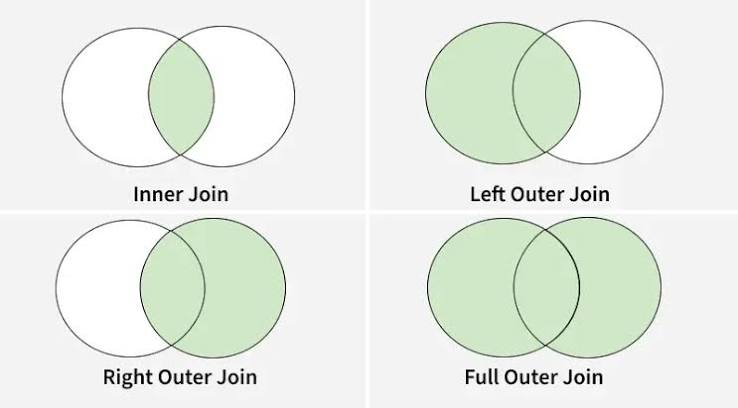

ในงานจริง ข้อมูลมักแยกอยู่หลายตาราง เช่น
- ตาราง **ผู้ป่วย** มีแค่ **รหัสโรงพยาบาล** → ชื่อโรงพยาบาลและจังหวัดอยู่ในอีก **ตารางรหัส (lookup table)**
- ตาราง **ผู้ป่วย** มีแค่ **รหัส ICD-10** → ชื่อโรคอยู่ในตารางรหัส ICD-10

`merge` คือการ **จับคู่แถว** ของ 2 ตาราง โดยใช้คอลัมน์ที่มีค่าเหมือนกัน เรียกว่า **key** (เหมือน `VLOOKUP` ใน Excel)

ข้อมูล Titanic มีตารางเดียว เราจึง **สร้างตารางรหัสท่าเรือ** ขึ้นมาเอง แล้วรวมเข้ากับ Titanic โดยใช้ `embarked` เป็น key

### 6.1 การ `Merge` เพื่อรวมตาราง


In [ ]:
ports = pd.DataFrame({
    "embarked": ["S", "C", "Q"],
    "port_th":  ["เซาแทมป์ตัน", "แชร์บูร์ก", "ควีนส์ทาวน์"],
    "country":  ["England", "France", "Ireland"],
})
ports

In [ ]:
df_merged = df_clean.merge(ports, on="embarked", how="left")
df_merged[["embarked", "embark_town", "port_th", "country"]].head()

**ตรวจทุกครั้งหลัง merge:** จำนวนแถวต้องเท่าเดิม และคอลัมน์ใหม่ต้องไม่มีค่าว่าง

In [ ]:
print("ก่อน merge:", df_clean.shape)
print("หลัง merge:", df_merged.shape, "(เพิ่มมา 2 คอลัมน์)")
print("country ว่าง:", df_merged["country"].isna().sum(), "แถว")

### 6.2 ใช้ `merge` ตรวจข้อมูลซ้ำระหว่าง 2 ตาราง

- ตาราง 1: ผู้โดยสาร Titanic 5 คนแรก
Titanic ไม่มีรหัสผู้โดยสาร เราจึงสร้าง `passenger_id` ขึ้นมาจากเลขแถว เพื่อใช้เป็น key

In [ ]:
import pandas as pd

titanic = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")

# สร้างรหัสผู้โดยสาร P001, P002, ... (zfill(3) = เติม 0 ข้างหน้าให้ครบ 3 หลัก)
titanic["passenger_id"] = ["P" + str(i + 1).zfill(3) for i in range(len(titanic))]

titanic5 = titanic[["passenger_id", "sex", "age", "survived"]].head(5)
titanic5

- ตาราง 2 (ข้อมูลสมมติ): รายชื่อผู้รอดชีวิตที่เรือกู้ภัยบันทึกไว้
สมมติว่าเรือกู้ภัยจดรายชื่อผู้รอดชีวิตที่ช่วยขึ้นมาได้ แยกเป็นอีกแหล่งข้อมูลหนึ่ง

In [ ]:
rescue = pd.DataFrame({
    "passenger_id": ["P002", "P003", "P004", "P009", "P010"],
    "sex":          ["female", "female", "female", "female", "female"],
    "age":          [38, 26, 53, 27, 14],
})
rescue

#### เทียบ 2 ตาราง
ทั้ง 2 ตารางมีคอลัมน์ `sex` และ `age` เหมือนกัน → ใช้ `suffixes=` เติมท้ายชื่อคอลัมน์ เพื่อบอกว่าค่ามาจากตารางไหน

In [ ]:
compare = titanic5.merge(rescue, on="passenger_id", how="outer",
                         indicator=True, suffixes=("_titanic", "_rescue"))
compare

In [ ]:
# นับแต่ละกลุ่ม
compare["_merge"].value_counts()

#### แยกดูทีละกลุ่ม

In [ ]:
# 1. ซ้ำกัน — มีในทั้ง 2 ตาราง
both = compare[compare["_merge"] == "both"]
both

In [ ]:
# 2. มีเฉพาะใน Titanic 5 คนแรก (ไม่อยู่ในรายชื่อเรือกู้ภัย)
only_titanic = compare[compare["_merge"] == "left_only"]
only_titanic

In [ ]:
# 3. มีเฉพาะในรายชื่อเรือกู้ภัย (ไม่อยู่ใน 5 คนแรกของเรา)
only_rescue = compare[compare["_merge"] == "right_only"]
only_rescue

🔎 ลองคิด:
- `P001`, `P005` ไม่อยู่ในรายชื่อเรือกู้ภัย → ดูคอลัมน์ `survived` จะเห็นว่า **ไม่รอดชีวิต** ข้อมูลจึงสอดคล้องกัน
- `P009`, `P010` มีเฉพาะในรายชื่อเรือกู้ภัย เพราะตาราง Titanic ที่เราดึงมามีแค่ 5 คนแรก

## **7.🧾 Data visualization**

3 ไลบรารีหลักที่เป็นตัวท็อปและนิยมที่สุด

**1. Matplotlib**
เปรียบเสมือน 'บิดาแห่งการวาดกราฟ' ใน Python
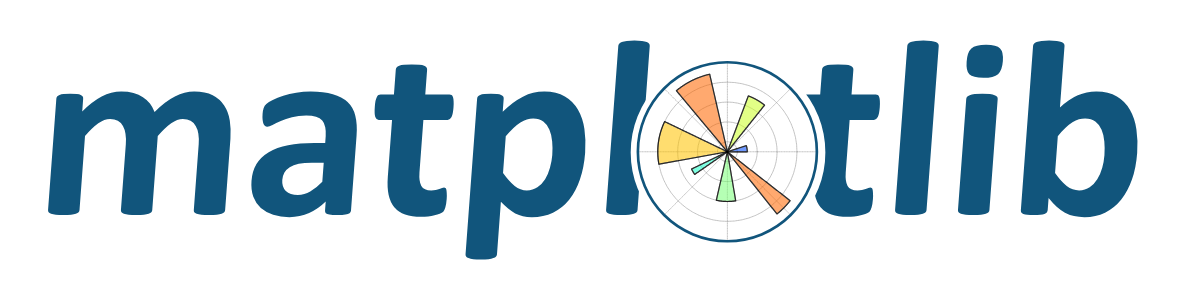

- จุดเด่นของ Matplotlib คือ ความยืดหยุ่นระดับสูงสุด ครับ มันยอมให้เราควบคุมทุกอย่างในกราฟได้ ตั้งแต่ขนาดตัวอักษร สีของเส้น ระยะห่างของแกน ไปจนถึงการจัดวางรูปหลายๆ รูปในหน้าเดียว

- แต่ข้อเสียเล็กๆ ของมันก็คือ ความละเอียดยิบ เพราะการจะได้กราฟสวยๆ สักรูป เราอาจจะต้องเขียนโค้ดถึง 5–10 บรรทัด ดังนั้น ในการทำงานจริง เรามักจะใช้ Matplotlib เป็นโครงสร้างพื้นฐานเบื้องหลังมากกว่า

**2. Seaborn** พระเอกงานสถิติและ EDA (The Statistical Powerhouse)
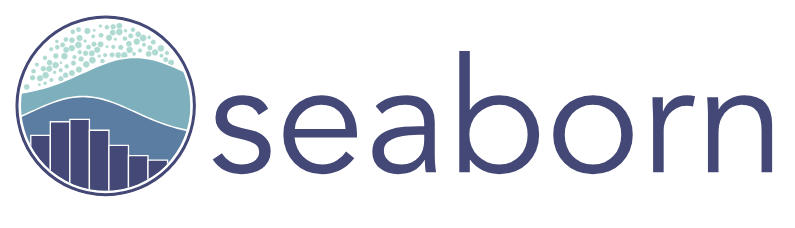
- จุดเด่นของ Seaborn คือ 'เขียนโค้ดน้อย แต่ได้รูปสวยทันสมัย' และถูกออกแบบมาเพื่อการทำ Statistical Visualization หรือการวิเคราะห์ข้อมูลทางสถิติโดยเฉพาะ

- คำสั่งของ Seaborn ทำงานร่วมกับ Pandas DataFrame ได้อย่างราบรื่นมาก แค่เราบอกว่า x คือคอลัมน์ไหน y คือคอลัมน์ไหน และอยากแยกสีกลุ่มด้วยพารามิเตอร์ hue แค่บรรทัดเดียว เราก็จะได้กราฟวิเคราะห์พฤติกรรมลูกค้า หรือความสัมพันธ์ของข้อมูลที่ดูมืออาชีพทันที

**3. Plotly** ยกระดับสู่ความ Interactive
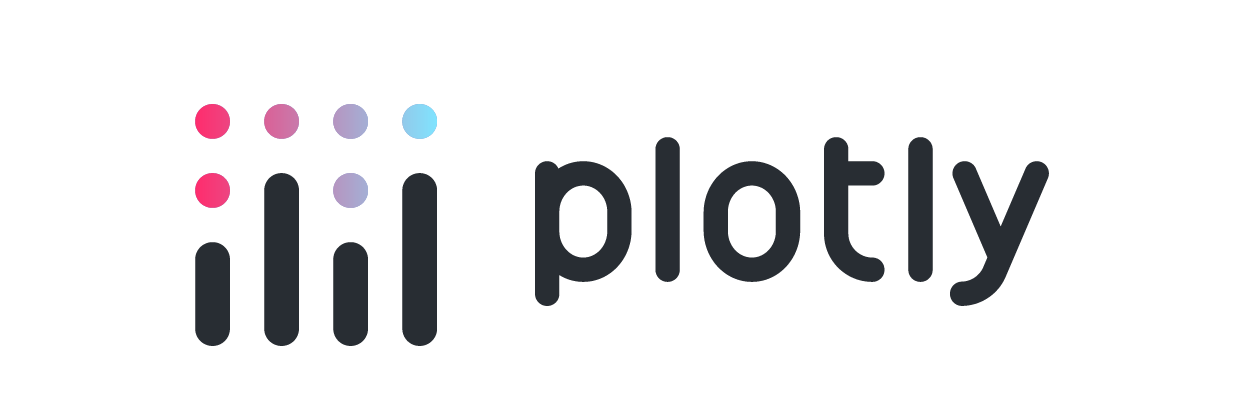
- ความเจ๋งของ Plotly คือ ยูสเซอร์สามารถเอาม้าไปขี้ (Hover) เพื่อดูค่าตัวเลขจริงได้ สามารถเลื่อนขยายซูมดูข้อมูลเฉพาะจุด หรือแม้กระทั่งกดซ่อน/แสดงหมวดหมู่จาก Legend ได้ทันที เหมาะมากๆ สำหรับการนำไปใส่ใน Executive Dashboard หรือ Slide นนำเสนอผลงานที่ต้องการความน่าตื่นตาตื่นใจ


💡 สรุปแล้ว เราควรเลือกใช้อะไรดี?

- อยากแต่งกราฟละเอียดทุกตารางนิ้ว / คุมโครงสร้าง: ใช้ Matplotlib

- อยากวิเคราะห์ข้อมูลเร็วๆ สวย สะอาด โค้ดสั้น: ใช้ Seaborn

- อยากได้กราฟ interactive นำเสนอผู้บริหาร / ทำ Web App: ใช้ Plotly

### 7.1 🚤 **Seaborn**

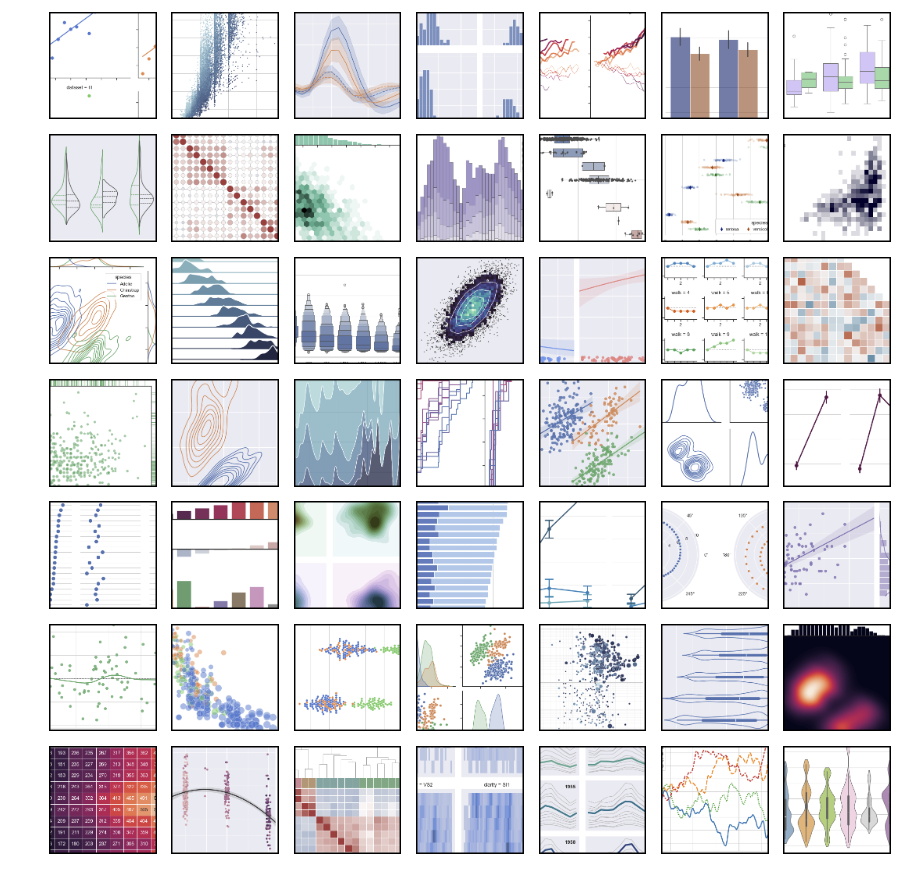

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# กำหนดสีประจำกลุ่มไว้ครั้งเดียว แล้วใช้ซ้ำทุกกราฟ (ทั้ง seaborn และ plotly)
# → ผู้ชายเป็นสีน้ำเงินเสมอ ผู้อ่านไม่ต้องเดาใหม่ทุกรูป
SEX_COLORS = {"male": "#2a78d6", "female": "#eb6834"}
ALIVE_COLORS = {"no": "#9e9d98", "yes": "#1baf7a"}

---
รูปแบบคำสั่งของ seaborn เหมือนกันทุกกราฟ:
```
plt.figure(figsize=(กว้าง, สูง))      # 1. สร้างพื้นที่วาด
sns.ชนิดกราฟ(data=ตาราง, x=..., y=...)   # 2. วาด
plt.title(...); plt.xlabel(...)         # 3. ใส่ชื่อกราฟ / แกน
plt.show()                              # 4. แสดงผล
```
> ⚠️ ตั้งชื่อกราฟ/แกนเป็น **ภาษาอังกฤษ** เพราะ matplotlib มักแสดงภาษาไทยเป็นสี่เหลี่ยม

#### **7.1.1 Histogram** — อายุของผู้โดยสารกระจายตัวอย่างไร?
`bins` = จำนวนแท่ง (ช่วง) ที่แบ่ง


seaborn.histplot() ใช้สร้าง ฮิสโทแกรม (histogram) เพื่อดูการกระจายตัว (distribution) ของข้อมูล โดยแบ่งข้อมูลเป็นช่วง (bin) แล้วนับจำนวนข้อมูลในแต่ละช่วง แสดงเป็นแท่งกราฟ


```python
sns.histplot(data, x)
```

พารามิเตอร์ที่ใช้บ่อยของ `sns.histplot()`

| พารามิเตอร์ | ค่าเริ่มต้น | ความหมาย | ตัวอย่างค่า |
|---|---|---|---|
| `data` | `None` | DataFrame ที่เก็บข้อมูล | `df` |
| `x` / `y` | `None` | คอลัมน์ที่ใช้พล็อต (`x` แนวนอน, `y` แนวตั้ง) | `"total_bill"` |
| `bins` | `'auto'` | จำนวน bin หรือรายการขอบเขต bin | `20`, `[0, 10, 20, 30]` |
| `binwidth` | `None` | ความกว้างของแต่ละ bin | `5` |
| `stat` | `'count'` | ค่าที่แสดงบนแกน | `'percent'`, `'density'` |
| `kde` | `False` | วาดเส้น KDE ซ้อนทับ | `True` |
| `hue` | `None` | แยกสีตามกลุ่มข้อมูล | `"sex"` |
| `multiple` | `'layer'` | วิธีวางหลายกลุ่ม: `layer` ซ้อนทับ, `stack` วางต่อกัน, `dodge` วางข้างกัน, `fill` รวมเป็น 100% | `'stack'` |
| `element` | `'bars'` | รูปแบบการวาด: `bars` แท่ง, `step` เส้นขั้นบันได, `poly` เส้นหลายเหลี่ยม | `'step'` |
| `cumulative` | `False` | แสดงแบบสะสม | `True` |
| `common_norm` | `True` | ถ้า `False` จะ normalize แยกแต่ละกลุ่ม (ใช้เปรียบเทียบกลุ่มที่ขนาดต่างกัน) | `False` |
| `color` | `None` | สีของกราฟ (ไม่ใช้ `hue`) | `"steelblue"` |
| `palette` | `None` | ชุดสีของแต่ละกลุ่มเมื่อใช้ `hue` | `"Set2"` |
| `log_scale` | `None` | ใช้สเกล log | `True` |
| `ax` | `None` | ระบุ matplotlib Axes ที่จะวาดลงไป | `ax=axes[0]` |

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df_clean, x="age", bins=20)
plt.title("Age distribution of passengers")
plt.xlabel("Age (years)")
plt.ylabel("Number of passengers")
plt.show()

🔎 แท่งที่สูงผิดปกติตรงอายุ 25–30 ปี มาจาก **การเติม median (28 ปี)** ในส่วนที่ 3 — กราฟช่วยให้เห็นผลของการทำความสะอาดข้อมูล

เพิ่ม `hue=` เพื่อแยกสีตามกลุ่ม — `multiple="stack"` = วางซ้อนกันเป็นชั้น

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df_clean, x="age", hue="alive", bins=20,
             multiple="stack", palette=ALIVE_COLORS)
plt.title("Age distribution by survival")
plt.xlabel("Age (years)")
plt.ylabel("Number of passengers")
plt.show()

#### **7.1.2 Bar chart** — ชั้นตั๋วและเพศไหนรอดมากที่สุด?
**ขั้นที่ 1:** สรุปด้วย `groupby` ก่อน — `.reset_index(name=...)` ทำให้ผลลัพธ์เป็นตารางปกติพร้อมวาด

- `boxplot` ให้ภาพรวมของ median, quartile และ outlier ในกราฟเดียว
แสดงการกระจายของข้อมูลตัวเลข (median, quartile, outlier) แยกตามกลุ่ม


  | พารามิเตอร์ | ค่าเริ่มต้น | ความหมาย | ตัวอย่างค่า |
  |---|---|---|---|
  | `data` | `None` | DataFrame ที่เก็บข้อมูล | `df` |
  | `x` / `y` | `None` | แกนหมวดหมู่ และแกนตัวเลข (สลับกันเพื่อเปลี่ยนเป็นแนวนอน) | `x="class", y="survival rate"` |
  | `hue` | `None` | แยกกล่องตามกลุ่มย่อยด้วยสี | `"sex"` |
  | `order` | `None` | กำหนดลำดับของหมวดหมู่บนแกน | `["First", "Second", "third"]` |




In [ ]:
rate = (df_clean.groupby(["class", "sex"])["survived"]
        .mean()
        .reset_index(name="survival_rate"))
rate

**ขั้นที่ 2:** วาด — `x` = กลุ่ม, `y` = ค่า, `hue` = แยกสีตามกลุ่มย่อย

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=rate, x="class", y="survival_rate", hue="sex",
            palette=SEX_COLORS, order=["First", "Second", "Third"])
plt.title("Survival rate by class and sex")
plt.xlabel("Ticket class")
plt.ylabel("Survival rate")
plt.show()

> 💡 **รู้ไว้:** `sns.barplot(data=df_clean, x="class", y="survived")` ใส่ข้อมูลดิบได้เลย seaborn จะคำนวณ **ค่าเฉลี่ย** ให้เอง
> พร้อม **เส้นสีดำ = ช่วงความเชื่อมั่น (confidence interval)** — สะดวก แต่ผู้เริ่มต้นมักไม่รู้ว่ากราฟคำนวณอะไร
>
> ถ้าแค่อยาก **นับจำนวน** ใช้ `sns.countplot(data=df_clean, x="class")`

#### **7.1.3 Line chart**

sns.lineplot() วาดกราฟเส้นแสดงแนวโน้มของ y ตามค่า x (ที่มีลำดับ เช่น เวลา, ขนาด)

  | พารามิเตอร์ | ค่าเริ่มต้น | ความหมาย | ตัวอย่างค่า |
  |---|---|---|---|
  | `data` | `None` | DataFrame ที่ใช้วาด (ใช้ร่วมกับ `x`, `y` ที่เป็นชื่อคอลัมน์) | `tips` |
  | `hue` | `None` | แยกเส้นตามกลุ่มด้วยสี | `'time'` |
  | `estimator` | `'mean'` | วิธีรวมค่า y ที่ x เดียวกัน (`None` = ไม่รวม) | `'median'`, `None` |
  | `errorbar` | `('ci', 95)` | ชนิดของแถบความไม่แน่นอน | `'sd'`, `None` |
  | `markers` | `None` | แสดงสั

อัตรารอดเปลี่ยนไปอย่างไรตามอายุ?

กราฟเส้นเหมาะกับแกน x ที่ **มีลำดับ** เช่น ปี เดือน หรืออายุ
(ข้อมูล Titanic ไม่มีวันที่ — ในงานทะเบียนมะเร็งมักใช้ **ปีที่วินิจฉัย** เป็นแกน x)

**ขั้นที่ 1:** แบ่งอายุเป็นช่วงละ 10 ปี (`//` = หารปัดเศษทิ้ง เช่น 37 // 10 = 3 → 3 × 10 = 30)

In [ ]:
df_clean["age_decade"] = (df_clean["age"] // 10 * 10).astype(int)
df_clean[["age", "age_decade"]].head()

**ขั้นที่ 2:** สรุปอัตรารอด **และจำนวนคน** ในแต่ละช่วงอายุ + เพศ

In [ ]:
trend = df_clean.groupby(["age_decade", "sex"]).agg(
    survival_rate=("survived", "mean"),
    n=("survived", "size"),
).reset_index()
trend.head(6)

**ขั้นที่ 3:** วาด — `marker="o"` ใส่จุดที่ข้อมูลแต่ละช่วง

In [ ]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=trend, x="age_decade", y="survival_rate", hue="sex",
             marker="o", palette=SEX_COLORS)
plt.title("Survival rate by age group (10-year bands)")
plt.xlabel("Age band (years)")
plt.ylabel("Survival rate")
plt.show()

🔎 สังเกตเส้นผู้ชายที่อายุ 80 พุ่งขึ้นไป 100% — แปลกไหม? เดี๋ยวเราจะใช้ **plotly** ชี้ดูว่าจุดนั้นมีกี่คน

#### **7.1.4 Heatmap** — ดูตาราง 2 มิติด้วยสี

  sns.heatmap() แสดงข้อมูลรูปแบบตาราง 2 มิติด้วยสี นิยมใช้กับ correlation matrix

  | พารามิเตอร์ | ค่าเริ่มต้น | ความหมาย | ตัวอย่างค่า |
  |---|---|---|---|
  | `data` | (จำเป็นต้องระบุ) | ข้อมูลแบบ 2 มิติ เช่น DataFrame หรือ array | `df.corr(numeric_only=True)` |
  | `annot` | `None` | แสดงตัวเลขในแต่ละช่อง | `True` |
  | `fmt` | `'.2g'` | รูปแบบตัวเลขของ annotation | `'.2f'`, `'d'` |
  | `cmap` | `None` | ชุดสีของแผนที่ความร้อน | `'coolwarm'`, `'viridis'` |
  | `center` | `None` | ค่ากลางของสเกลสี เหมาะกับข้อมูลที่มีทั้งค่าบวกและลบ | `0` |

**ขั้นที่ 1:** สร้างตารางด้วย `groupby` + `.unstack()` (เหมือนส่วนที่ 5.3)

In [ ]:
table = (df_clean.groupby(["class", "age_group"])["survived"]
         .mean()
         .unstack())

# เรียงคอลัมน์ให้เป็นลำดับอายุ (ไม่งั้นจะเรียงตามตัวอักษร)
table = table[["child", "adult", "elderly"]]
table

**ขั้นที่ 2:** วาด — `annot=True` แสดงตัวเลขในช่อง, `fmt=".0%"` แสดงเป็น %, `cmap="Blues"` = สีเดียว อ่อน→เข้ม

In [ ]:
plt.figure(figsize=(6, 3.5))
sns.heatmap(table, annot=True, fmt=".0%", cmap="Blues", vmin=0, vmax=1,
            linewidths=2, linecolor="white")
plt.title("Survival rate by class and age group")
plt.xlabel("Age group")
plt.ylabel("Ticket class")
plt.show()

#### **7.1.5 Scatter plot**


แสดงความสัมพันธ์ระหว่างตัวแปรตัวเลข 2 ตัว โดยแต่ละจุดคือข้อมูล 1 แถว

  | พารามิเตอร์ | ค่าเริ่มต้น | ความหมาย | ตัวอย่างค่า |
  |---|---|---|---|
  | `data` | `None` | DataFrame ที่เก็บข้อมูล | `df` |
  | `x` / `y` | `None` | คอลัมน์ตัวเลขสำหรับแกนนอนและแกนตั้ง | `x="total_bill", y="tip"` |
  | `hue` | `None` | แยกสีของจุดตามกลุ่มหรือค่าของตัวแปร | `"sex"` |
  | `size` | `None` | ปรับขนาดจุดตามค่าของตัวแปร (min,max) | `(30,250)` |
  | `alpha` | `1` | ความโปร่งใสของจุด 0 ถึง 1 (ส่งผ่าน `**kwargs` ไปยัง matplotlib) ช่วยให้เห็นจุดที่ซ้อนกัน | `0.5` |

💵 **Tips Dataset**

ข้อมูลจากพนักงานเสิร์ฟร้านอาหารแห่งหนึ่ง บันทึกยอดบิลและทิปของลูกค้าแต่ละโต๊ะ (244 แถว)

| คอลัมน์ | ความหมาย | ชนิดข้อมูล |
|---|---|---|
| `total_bill` | ยอดบิลรวม (USD) | ตัวเลขต่อเนื่อง |
| `tip` | ทิป (USD) | ตัวเลขต่อเนื่อง |
| `sex` | เพศของผู้จ่ายบิล | หมวดหมู่ |
| `smoker` | อยู่โซนสูบบุหรี่หรือไม่ | หมวดหมู่ |
| `day` | วันในสัปดาห์ (Thur–Sun) | หมวดหมู่ |
| `time` | มื้ออาหาร (Lunch / Dinner) | หมวดหมู่ |
| `size` | จำนวนคนในโต๊ะ | จำนวนเต็ม |

In [ ]:
tips = sns.load_dataset('tips')
print(len(tips))
display(tips.head())

In [ ]:
sns.scatterplot(
    data=tips,
    x="total_bill", y="tip",
    hue="time", size="size", sizes=(30, 250),
    alpha=0.7,
)
plt.title("Total Bill vs Tip")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

---
### 7.2 **🖱️ Plotly**



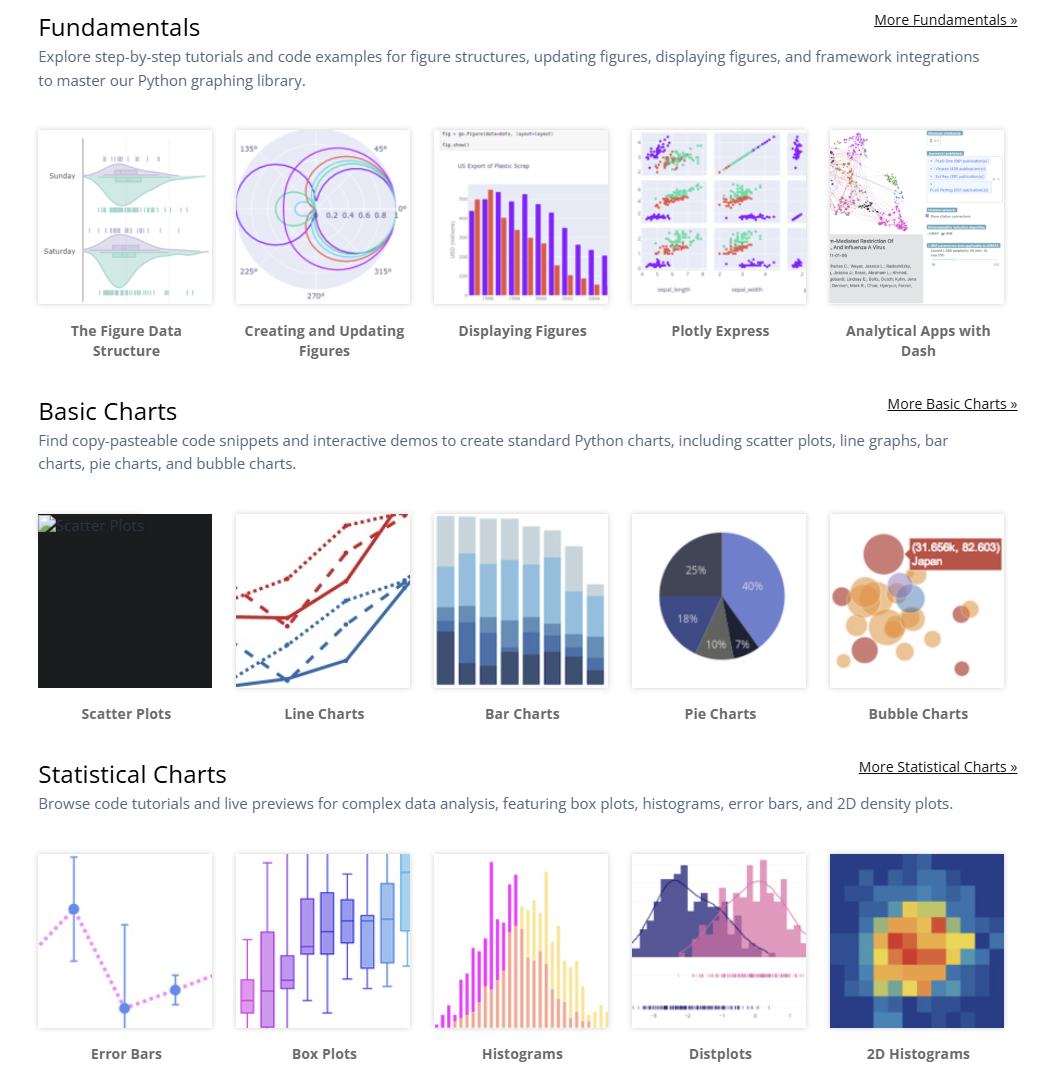

**Plotly interactive graph**

เหมาะกับการใช้นำเสนอ, เว็บ, dashboard

| การกระทำ | ผลลัพธ์ |
|---|---|
| เอาเมาส์ชี้ที่จุด | แสดงค่า (hover) |
| ลากเป็นกรอบ | zoom เข้า |
| ดับเบิลคลิก | กลับสู่มุมมองเดิม |
| คลิกชื่อกลุ่มใน legend | ซ่อน/แสดงกลุ่ม (ดับเบิลคลิก = แสดงเฉพาะกลุ่มนั้น) |
| ปุ่มกล้องที่มุมขวาบน | บันทึกเป็นรูป PNG |


#### 7.2.1 Histogram

In [ ]:
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = px.histogram(df_clean, x="age", nbins=20, color="alive",
                   color_discrete_map=ALIVE_COLORS,
                   title="การกระจายตัวของอายุ แยกตามการรอดชีวิต",
                   labels={"age": "อายุ (ปี)", "alive": "รอดชีวิต"})
fig.show()

🖱️ ลอง: ชี้ที่แท่ง → เห็นจำนวน · คลิก `yes` ใน legend → ซ่อนกลุ่มนั้น · ลากคลุมพื้นที่ → ซูม (ดับเบิลคลิกเพื่อกลับ)

#### 7.2.1 Bar chart



`px.bar()` วาดแผนภูมิแท่งเพื่อเปรียบเทียบค่าระหว่างกลุ่ม **ไม่ aggregate ให้เอง** จึงต้อง `groupby` สรุปค่าก่อน

| พารามิเตอร์ | ค่าเริ่มต้น | ความหมาย | ตัวอย่างค่า |
|---|---|---|---|
| `color` | `None` | แยกสีแท่งตามกลุ่มย่อย | `"time"` |
| `barmode` | `'relative'` | การจัดแท่งของกลุ่มย่อย (`relative` = ซ้อนกัน) | `"group"` (เคียงกัน), `"overlay"` (ทับกัน) |
| `text_auto` | `False` | แสดงตัวเลขบนแท่ง | `True`, `".1f"` |
| `orientation` | `None` | ทิศทางแท่ง (ถ้าไม่ระบุ = ตั้งตามชนิดข้อมูลของแกน) | `"h"` (แนวนอน), `"v"` (แนวตั้ง) |
| `category_orders` | `None` | กำหนดลำดับของหมวดหมู่บนแกน | `{"day": ["Thur", "Fri", "Sat", "Sun"]}` |


ถ้าอยากได้ **แท่งแนวนอน** ให้สลับ x กับ y แล้วใส่ `orientation="h"`:

```python
px.bar(summary, x="tip_pct", y="day", color="time", orientation="h", barmode="group")
```

In [ ]:
fig = px.bar(rate, x="class", y="survival_rate", color="sex",
             barmode="group",
             color_discrete_map=SEX_COLORS,
             text_auto=".0%",
             category_orders={"class": ["First", "Second", "Third"]},
             title="อัตรารอดชีวิต แยกตามชั้นตั๋วและเพศ",
             labels={"class": "ชั้นตั๋ว", "survival_rate": "อัตรารอดชีวิต", "sex": "เพศ"})
fig.update_yaxes(tickformat=".0%")
fig.show()

#### 7.2.2 Line chart
ใส่ `hover_data=["n"]` เพื่อให้ชี้เมาส์แล้วเห็น **จำนวนคน** ในจุดนั้นด้วย



`px.line()` วาดกราฟเส้นแสดงแนวโน้มตามค่า x ที่มีลำดับ ไม่ aggregate ให้เองจึงต้อง `groupby` สรุปค่าก่อน


```python
trend = df_clean.groupby(["age_decade", "sex"]).agg(
    survival_rate=("survived", "mean"),
    n=("survived", "size"),
).reset_index()
```



| พารามิเตอร์ | ค่าเริ่มต้น | ความหมาย | ตัวอย่างค่า |
|---|---|---|---|
| `color` | `None` | แยกเส้นตามกลุ่มด้วยสี | `"time"` |
| `line_dash` | `None` | แยกเส้นตามกลุ่มด้วยลายเส้น (ทึบ/ประ) | `"sex"` |
| `markers` | `False` | แสดงจุดบนเส้น | `True` |
| `line_shape` | `None` | รูปแบบการเชื่อมจุด (ถ้าไม่ระบุ = เส้นตรง) | `"spline"` (โค้ง), `"hv"` (ขั้นบันได) |
| `error_y` | `None` | คอลัมน์ความคลาดเคลื่อนของแกน y วาดเป็นแท่ง error | `"sem"` |


**ข้อควรระวัง**
- `px.line` ต่อจุดตามลำดับแถวใน DataFrame ไม่ได้เรียงแกน x ให้ ถ้าข้อมูลไม่ได้เรียงมา เส้นอาจซิกแซก ให้ใช้ `sort_values("x")` ก่อน (ผลจาก `groupby` เรียงให้อยู่แล้ว)

In [ ]:
fig = px.line(trend, x="age_decade", y="survival_rate", color="sex",
              markers=True, hover_data=["n"],
              color_discrete_map=SEX_COLORS,
              title="อัตรารอดชีวิต ตามช่วงอายุ",
              labels={"age_decade": "ช่วงอายุ (ปี)", "survival_rate": "อัตรารอดชีวิต", "sex": "เพศ"})
fig.update_yaxes(tickformat=".0%")
fig.show()

🔎 ลองชี้ที่จุดผู้ชายอายุ 80 — `n = 1` จุดที่พุ่งขึ้นไป 100% มาจาก **คนเพียง 1 คน**!
ผู้หญิงอายุ 60+ ก็มีแค่ 3 คน ผู้ชายอายุ 70+ มีแค่ 7 คน เส้นจึงกระโดดขึ้นลงมาก
**อย่าตีความกลุ่มที่มีคนน้อย** — ควรดูจำนวน `n` คู่กับอัตราเสมอ

### 7.3 Save interactive graph
- การ SAVE Interactive graph ไปใช้  ทำโดย

  | วิธี | ผลลัพธ์ | ข้อควรรู้ |
  |---|---|---|
  | `fig.write_html("a.html")` | ไฟล์ HTML ที่ยัง interactive | เปิดในเบราว์เซอร์ได้เลย ไม่ต้องมี Python |
  | `fig.write_html("a.html", include_plotlyjs="cdn")` | เหมือนข้างบน แต่ไฟล์เล็กลงมาก (~ KB แทนที่จะเป็น ~ MB) | ผู้เปิดต้องต่ออินเทอร์เน็ต |
  | `fig.write_image("a.png")` | รูปภาพนิ่ง (PNG, SVG, PDF) | ต้องติดตั้ง `kaleido` (`pip install kaleido`) |

In [ ]:
fig = px.scatter(tips, x="total_bill", y="tip", color="time", title="Bill vs Tip")

fig.write_html("tips_scatter.html")
print("บันทึกแล้ว: tips_scatter.html")

---
## 📋 สรุปคำสั่ง (Cheat sheet)

| งาน | คำสั่ง |
|---|---|
| อ่านไฟล์ CSV | `pd.read_csv("file.csv")` |
| ขนาดข้อมูล | `df.shape` |
| ดูตัวอย่าง | `df.head()` · `df.tail()` · `df.sample(5)` |
| ชนิดข้อมูล + non-null | `df.info()` · `df.dtypes` |
| สถิติเบื้องต้น | `df.describe()` · `df.describe(exclude="number")` |
| นับค่า | `df["col"].value_counts(dropna=False)` |
| กรองแถว | `df[df["col"] > 10]` · `df[(เงื่อนไข1) & (เงื่อนไข2)]` |
| แถวซ้ำ | `df.duplicated().sum()` · `df.duplicated(subset=["id"])` |
| ดูแถวซ้ำทั้งหมด | `df[df.duplicated(keep=False)]` |
| ลบแถวซ้ำ | `df.drop_duplicates()` |
| นับค่าว่าง | `df.isna().sum()` · `df.isna().mean() * 100` |
| ลบคอลัมน์ | `df.drop(columns=["col"])` |
| ลบแถวที่ว่าง | `df.dropna(subset=["col"])` |
| เติมค่าว่าง | `df["col"] = df["col"].fillna(ค่า)` |
| เติมตามกลุ่ม | `df["col"].fillna(df.groupby("g")["col"].transform("median"))` |
| แปลงค่าว่างแฝง | `df.replace(["-", "N/A"], np.nan)` |
| นับจำนวนตามกลุ่ม | `df.groupby("col").size()` |
| คำนวณตามกลุ่ม | `df.groupby("col")["x"].mean()` · `.sum()` · `.max()` |
| แบ่ง 2 กลุ่ม เป็นตาราง | `df.groupby(["a", "b"]).size().unstack()` |
| หลายค่าสรุปพร้อมกัน | `df.groupby("col").agg(n=("x", "size"), avg=("x", "mean"))` |
| รวมตาราง | `df.merge(lookup, on="key", how="left")` |
| Histogram | `sns.histplot(data=df, x="age", hue="g")` · `px.histogram(df, x="age", color="g")` |
| Bar | `sns.barplot(data=t, x="g", y="v", hue="h")` · `px.bar(t, x="g", y="v", color="h", barmode="group")` |
| Line | `sns.lineplot(data=t, x="x", y="v", hue="h", marker="o")` · `px.line(t, x="x", y="v", color="h", markers=True)` |
| Heatmap | `sns.heatmap(table, annot=True, cmap="Blues")` · `px.imshow(table, text_auto=True)` |
| สร้างฟังก์ชัน | `def ชื่อ(x):` → `if` / `elif` / `else` → `return` |
| ใช้ฟังก์ชันกับทั้งคอลัมน์ | `df["new"] = df["col"].apply(ชื่อฟังก์ชัน)` |
| เช็กว่า 2 คอลัมน์ตรงกันทุกแถว | `(df["a"] == df["b"]).all()` |
| บันทึกไฟล์ | `df.to_csv("out.csv", index=False)` |

### ✅ Checklist ก่อนวิเคราะห์ข้อมูลทุกครั้ง
- [ ] รู้ขนาดข้อมูล และความหมายของแต่ละคอลัมน์
- [ ] ชนิดข้อมูลถูกต้อง (ตัวเลขไม่ได้ถูกอ่านเป็นข้อความ)
- [ ] ตรวจแถวซ้ำ — และ **ตัดสินใจด้วยความรู้เรื่องข้อมูล** ว่าจะลบหรือไม่
- [ ] ตรวจค่าว่าง (รวมถึงค่าว่างแฝง เช่น `"-"`, `"ไม่ทราบ"`)
- [ ] จดไว้ว่าจัดการค่าว่างด้วยวิธีใด เพราะมีผลต่อผลวิเคราะห์
- [ ] ทดสอบฟังก์ชันแปลงข้อมูลกับค่าทีละตัวก่อน แล้วตรวจผลด้วย `value_counts()` ว่าไม่มี `error`
- [ ] หลัง `merge` ตรวจว่าจำนวนแถวเท่าเดิม และคอลัมน์ใหม่ไม่มีค่าว่าง
- [ ] ทำงานบนสำเนา เก็บข้อมูลดิบไว้เสมอ

## 8.Answer

### เฉลย ข้อ 1.1
**1.1** ค่าตั๋ว (`fare`) แพงที่สุดเท่าไร? (ใช้ `.max()`)

In [ ]:
df["fare"].max()

### เฉลย ข้อ 1.2
**1.2** ผู้โดยสารขึ้นเรือจากท่าไหนมากที่สุด? (ใช้ `value_counts()` กับ `embark_town`)

In [ ]:
df["embark_town"].value_counts()
# คำตอบ: Southampton

### เฉลย ข้อ 1.3
**1.3** มีผู้โดยสารชั้น 3 (`pclass == 3`) ที่รอดชีวิต (`survived == 1`) กี่คน?

In [ ]:
third_survived = df[(df["pclass"] == 3) & (df["survived"] == 1)]
len(third_survived)

### เฉลย ข้อ 1.4 ⏭️ (ท้าทาย)
**1.4 ⏭️ (ท้าทาย)** อัตรารอดชีวิตของผู้หญิงกับผู้ชายต่างกันแค่ไหน?

In [ ]:
df.groupby("sex")["survived"].mean()
# ผู้หญิงรอดประมาณ 74% ผู้ชายรอดประมาณ 19%

### เฉลย ข้อ 2.1
**2.1** ในข้อมูล Titanic ถ้าดูแค่คอลัมน์ `sex`, `age`, `pclass` จะมีแถวที่ซ้ำกันกี่แถว?

In [ ]:
df.duplicated(subset=["sex", "age", "pclass"]).sum()
# ตัวเลขมากขึ้น เพราะยิ่งดูน้อยคอลัมน์ โอกาสที่หลายคนจะมีค่าตรงกันก็ยิ่งสูง

### เฉลย ข้อ 2.2
**2.2** สร้างตารางผู้ป่วยต่อไปนี้ แล้วหาว่า `hn` (เลขประจำตัวผู้ป่วย) ไหนซ้ำบ้าง และลบแถวที่ซ้ำ **ทุกคอลัมน์** ออก

In [ ]:
visits = pd.DataFrame({
    "hn":    ["A01", "A02", "A01", "A03", "A02", "A01"],
    "visit": ["2026-01-05", "2026-01-06", "2026-01-05", "2026-01-07", "2026-02-10", "2026-03-01"],
    "dx":    ["C50", "C34", "C50", "C18", "C34", "C50"],
})

# hn ที่ซ้ำ
print(visits[visits.duplicated(subset=["hn"], keep=False)])

# ลบแถวที่ซ้ำทุกคอลัมน์ (A01 วันที่ 2026-01-05 บันทึกซ้ำ 2 ครั้ง)
visits_clean = visits.drop_duplicates().reset_index(drop=True)
visits_clean
# หมายเหตุ: hn ซ้ำแต่คนละวันที่ = มาโรงพยาบาลหลายครั้ง ไม่ใช่ข้อมูลซ้ำ ไม่ควรลบ

### เฉลย ข้อ 3.1
**3.1** คอลัมน์ `embark_town` มีค่าว่างกี่ช่องในข้อมูลดิบ `df`? และใน `df_clean` เหลือกี่ช่อง? ทำไม?

In [ ]:
print("df       :", df["embark_town"].isna().sum())
print("df_clean :", df_clean["embark_town"].isna().sum())
# เหลือ 0 เพราะ 2 แถวที่ embark_town ว่าง เป็นแถวเดียวกับที่ embarked ว่าง ซึ่งเราลบไปแล้ว

### เฉลย ข้อ 3.2
**3.2** แทนที่จะลบ 2 แถวที่ `embarked` ว่าง ให้ลอง **เติมด้วยค่าที่พบบ่อยที่สุด (mode)** ลงในสำเนาใหม่

In [ ]:
df_ex = df.copy()

most_common = df_ex["embarked"].mode()[0]
print("ค่าที่พบบ่อยที่สุด:", most_common)

df_ex["embarked"] = df_ex["embarked"].fillna(most_common)
df_ex["embarked"].isna().sum()

### เฉลย ข้อ 3.3
**3.3** เติมอายุที่ว่างด้วย **mean** แทน median ลงใน `df_ex` แล้วเปรียบเทียบค่าเฉลี่ยอายุก่อนและหลังเติม — เปลี่ยนไปไหม? ทำไม?

In [ ]:
print("ค่าเฉลี่ยอายุก่อนเติม:", round(df_ex["age"].mean(), 2))
df_ex["age"] = df_ex["age"].fillna(df_ex["age"].mean())
print("ค่าเฉลี่ยอายุหลังเติม:", round(df_ex["age"].mean(), 2))
# ค่าเฉลี่ยไม่เปลี่ยน เพราะเติมด้วยค่าเฉลี่ยเอง แต่ส่วนเบี่ยงเบนมาตรฐาน (std) จะลดลง
# ข้อมูลดู "นิ่ง" กว่าความจริง

### เฉลย ข้อ 4.1
**4.1** เขียนฟังก์ชัน `class_number` แปลงคอลัมน์ `class` (`First` / `Second` / `Third`) เป็นตัวเลข `1` / `2` / `3`

In [ ]:
def class_number(c):
    if c == "First":
        return 1
    elif c == "Second":
        return 2
    elif c == "Third":
        return 3
    else:
        return "error"

df_clean["class_no"] = df_clean["class"].apply(class_number)
(df_clean["class_no"] == df_clean["pclass"]).all()

### เฉลย ข้อ 4.2
**4.2** เขียนฟังก์ชันแปลงคอลัมน์ `alive` (`yes` / `no`) เป็น `1` / `0` แล้วเช็กคำตอบกับคอลัมน์ `survived`

In [ ]:
def alive_to_number(a):
    if a == "yes":
        return 1
    elif a == "no":
        return 0
    else:
        return "error"

df_clean["alive_no"] = df_clean["alive"].apply(alive_to_number)
(df_clean["alive_no"] == df_clean["survived"]).all()

### เฉลย ข้อ 4.3 ⏭️ (ท้าทาย)
**4.3 ⏭️ (ท้าทาย)** เขียนฟังก์ชัน `fare_level` แบ่งค่าตั๋ว (`fare`) เป็น 3 ระดับ

In [ ]:
def fare_level(fare):
    if fare < 10:
        return "low"
    elif fare < 50:
        return "medium"
    else:
        return "high"

df_clean["fare_level"] = df_clean["fare"].apply(fare_level)
print(df_clean["fare_level"].value_counts())
print(df_clean.groupby("fare_level")["survived"].mean().round(3))

### เฉลย ข้อ 5.1
**5.1** ผู้โดยสารขึ้นเรือจากแต่ละเมืองท่า (`embark_town`) กี่คน?

In [ ]:
df_clean.groupby("embark_town").size()

### เฉลย ข้อ 5.2
**5.2** นับจำนวนผู้โดยสาร แยกตามกลุ่มอายุ (`age_group`) และเพศ (`sex`) แล้วแสดงเป็นตารางด้วย `.unstack()`

In [ ]:
df_clean.groupby(["age_group", "sex"]).size().unstack()

### เฉลย ข้อ 5.3
**5.3** สร้างตารางสรุปแยกตาม `embark_town` ที่มี: จำนวนคน, จำนวนคนรอด, อัตรารอด และค่าตั๋วเฉลี่ย

In [ ]:
df_clean.groupby("embark_town").agg(
    n_passengers=("survived", "size"),
    n_survived=("survived", "sum"),
    survival_rate=("survived", "mean"),
    mean_fare=("fare", "mean"),
).round(2)